In [1]:
%reload_ext autoreload
%autoreload 2

# Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

import warnings
%matplotlib inline
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth',200)

# Task 2

## Load Iris Data

In [3]:
iris = load_iris(as_frame=True)

In [4]:
X = iris.data
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
y = iris.target
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [6]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [7]:
y.value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

## Split data

In [8]:
random_state = 42
test_size = 0.1
val_size = 0.111

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=val_size, stratify=y_train_val, random_state=random_state)

In [9]:
y_test.value_counts()

target
1    5
2    5
0    5
Name: count, dtype: int64

In [10]:
y_val.value_counts()

target
2    5
0    5
1    5
Name: count, dtype: int64

In [11]:
y_train.value_counts()

target
2    40
0    40
1    40
Name: count, dtype: int64

## Task 2.2: Classical Baseline on Structured Data

- Train a tree-based classifier (e.g. Decision Tree or Random Forest)
- Evaluate the model on the test set and report results.

In [13]:
from sklearn import tree
clf = tree.DecisionTreeClassifier(max_depth=3, random_state=42)
clf = clf.fit(X_train, y_train)

In [14]:
print(f"Training Accuracy: {clf.score(X_train, y_train):.4f}")

Training Accuracy: 0.9833


In [15]:
y_pred = clf.predict(X_test)

### Model behavior

In [16]:
from sklearn.metrics import classification_report, accuracy_score

cls_report = classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(cls_report)

Test Accuracy: 0.93

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      0.80      0.89         5
           2       0.83      1.00      0.91         5

    accuracy                           0.93        15
   macro avg       0.94      0.93      0.93        15
weighted avg       0.94      0.93      0.93        15



### Feature importance

In [17]:
importance = pd.Series(clf.feature_importances_, index=iris.feature_names).sort_values(ascending=False)

print("Feature Importance:")
print(importance)

Feature Importance:
petal length (cm)    0.557159
petal width (cm)     0.442841
sepal length (cm)    0.000000
sepal width (cm)     0.000000
dtype: float64


In [18]:
importance

petal length (cm)    0.557159
petal width (cm)     0.442841
sepal length (cm)    0.000000
sepal width (cm)     0.000000
dtype: float64

[Text(0.375, 0.875, 'petal length (cm) <= 2.45\ngini = 0.667\nsamples = 120\nvalue = [40, 40, 40]\nclass = setosa'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]\nclass = setosa'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'petal width (cm) <= 1.65\ngini = 0.5\nsamples = 80\nvalue = [0, 40, 40]\nclass = versicolor'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'petal length (cm) <= 4.95\ngini = 0.093\nsamples = 41\nvalue = [0, 39, 2]\nclass = versicolor'),
 Text(0.125, 0.125, 'gini = 0.0\nsamples = 38\nvalue = [0, 38, 0]\nclass = versicolor'),
 Text(0.375, 0.125, 'gini = 0.444\nsamples = 3\nvalue = [0, 1, 2]\nclass = virginica'),
 Text(0.75, 0.375, 'petal length (cm) <= 4.85\ngini = 0.05\nsamples = 39\nvalue = [0, 1, 38]\nclass = virginica'),
 Text(0.625, 0.125, 'gini = 0.444\nsamples = 3\nvalue = [0, 1, 2]\nclass = virginica'),
 Text(0.875, 0.125, 'gini = 0.0\nsamples = 36\nvalue = [0, 0, 36]\nclass = virginica')]

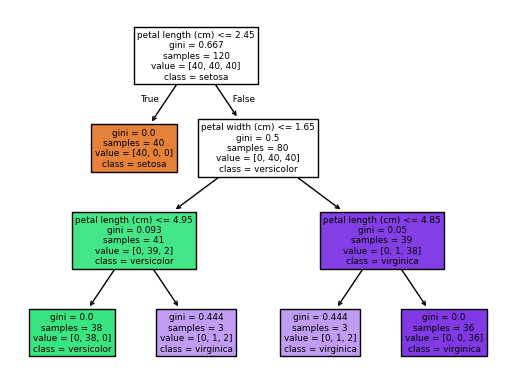

In [19]:
tree.plot_tree(clf, filled=True, feature_names=iris.feature_names, class_names=iris.target_names)

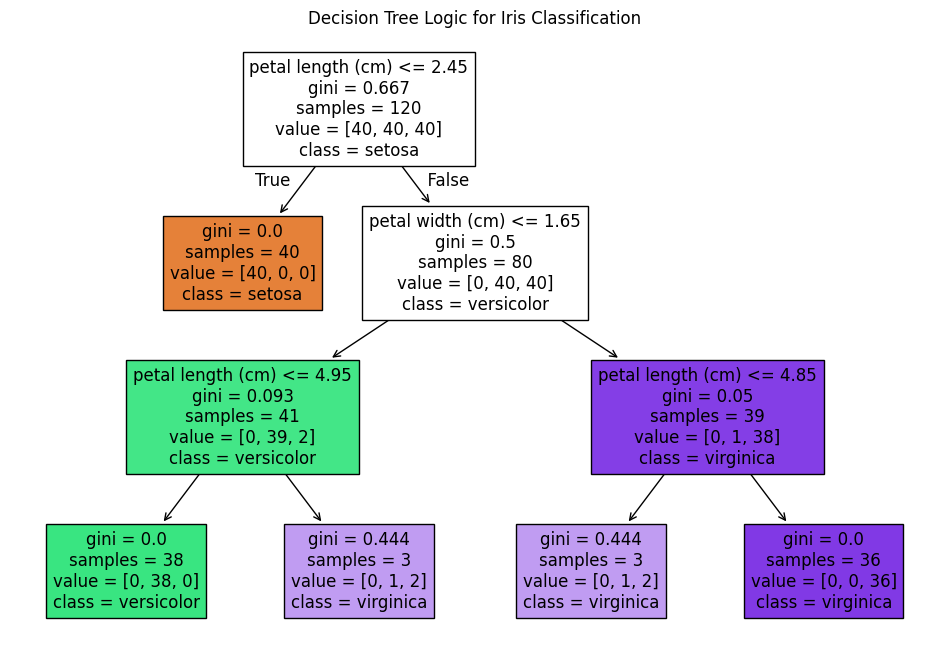

In [20]:
plt.figure(figsize=(12, 8))
tree.plot_tree(clf, filled=True, feature_names=iris.feature_names, class_names=iris.target_names)
plt.title("Decision Tree Logic for Iris Classification")
plt.show()

## Task 2.1 Report:

We selected a Decision Tree as our classical baseline primarily for i
interpretability and transparency. Given that Task 2.3 requires augmenting an LLM with structured information such as decision rules and feature importance, a Decision Tree provides an accessible 'white-box' logic that other models lack. Furthermore, the tree’s ability to perform automatic feature selection provided immediate insight into the characteristics of the Iris dataset.
## Model Behavior

We observed distinct behaviors between the unconstrained and constrained Decision Tree models.

- Overfitting in the Unconstrained Model: Initially, without a depth limit, the model achieved 100% training accuracy but only 87% test accuracy. This indicates overfitting, where the model memorized specific training examples rather than learning generalizable rules.
- Improved Generalization with Pruning: By setting max_depth=3, we forced the model to focus on the most significant patterns. Although training accuracy dropped slightly to 98.3%, the test accuracy improved to 93%, demonstrating better generalization to unseen data.

## Feature Importance
The model identified petal length and petal width as the sole determinants for classification. Sepal length and sepal width received importance scores of 0.00, indicating that the decision logic relied entirely on petal dimensions. The model effectively performed automatic feature selection, determining that sepal measurements were redundant for this specific classification task.

## Strengths and Limitations

**Strengths:**
- **Interpretability:** The model is a "white-box," meaning its classification logic is transparent and explainable.
- **Efficiency:** It requires minimal data preprocessing (like scaling) and is computationally very fast to train on small datasets.
- **Feature Selection:** It naturally identifies and prioritizes the most discriminative features (e.g., petal dimensions).

**Limitations:**
- **Overfitting:** Without constraints like `max_depth`, the model tends to "memorize" the training data, leading to poor performance on unseen test data
- **Instability:** Small changes in the training data can result in a completely different tree structure, making it less robust than some ensemble methods.





---

## Task 2.2: Textification and Transformer-Based Modeling

In [21]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [22]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

Justification for A: Transformers are pre-trained on massive amounts of natural text (books, Wikipedia). Using full sentences might make it easier for the model to "understand" the context of the numbers.

Justification for B: In real-world NLP, we often have limited space or tokens. A compact format is more "token-efficient," meaning the model processes fewer pieces of information to reach the same conclusion.

In [23]:
def textify_iris(features, representation_type="A"):
    text_data = []

    feat_names = ["sepal length", "sepal width", "petal length", "petal width"]

    for row in features.itertuples(index=False):
        if representation_type == "A":
            # Natural-language descriptions of feature values
            text = (f"the flower has a {feat_names[0]} of {row[0]}cm, a {feat_names[1]} of {row[1]}cm, "
                    f"a {feat_names[2]} of {row[2]}cm, and a {feat_names[3]} of {row[3]}cm.")
        else:
            # semi-structured text formats
            text = f"sl:{row[0]} sw:{row[1]} pl:{row[2]} pw:{row[3]}"

        text_data.append(text)


    return text_data


In [24]:
from datasets import Dataset, DatasetDict

def get_dataset(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    representation_type="A",
    print_examples=True,
):
    # Build text for the requested representation
    train_text = textify_iris(features=X_train, representation_type=representation_type)
    val_text   = textify_iris(features=X_val,   representation_type=representation_type)
    test_text  = textify_iris(features=X_test,  representation_type=representation_type)

    # Basic sanity checks
    assert len(train_text) == len(y_train), "Train text/label length mismatch"
    assert len(val_text)   == len(y_val),   "Val text/label length mismatch"
    assert len(test_text)  == len(y_test),  "Test text/label length mismatch"

    dataset = DatasetDict({
        "train": Dataset.from_dict({"text": train_text, "label": y_train}),
        "val":   Dataset.from_dict({"text": val_text,   "label": y_val}),
        "test":  Dataset.from_dict({"text": test_text,  "label": y_test}),
    })

    if print_examples:
        print(f"Representation {representation_type} examples:")
        for split in ["train", "val", "test"]:
            ex = dataset[split][0]
            print(f"\n[{split}] label={ex['label']}\n{ex['text']}")
    return dataset


In [25]:
dsA = get_dataset(X_train, y_train, X_val, y_val, X_test, y_test, representation_type="A")

Representation A examples:

[train] label=2
the flower has a sepal length of 6.8cm, a sepal width of 3.0cm, a petal length of 5.5cm, and a petal width of 2.1cm.

[val] label=2
the flower has a sepal length of 6.5cm, a sepal width of 3.0cm, a petal length of 5.8cm, and a petal width of 2.2cm.

[test] label=1
the flower has a sepal length of 6.6cm, a sepal width of 2.9cm, a petal length of 4.6cm, and a petal width of 1.3cm.


In [26]:
dsB = get_dataset(X_train, y_train, X_val, y_val, X_test, y_test, representation_type="B")

Representation B examples:

[train] label=2
sl:6.8 sw:3.0 pl:5.5 pw:2.1

[val] label=2
sl:6.5 sw:3.0 pl:5.8 pw:2.2

[test] label=1
sl:6.6 sw:2.9 pl:4.6 pw:1.3


In [50]:
import json
from pathlib import Path

import numpy as np
import evaluate

from IPython.display import display, Markdown
import pandas as pd

from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    EarlyStoppingCallback,
    Trainer,
)

metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")


def load_config(config_path: str) -> dict:
    p = Path(config_path)
    if not p.exists():
        raise FileNotFoundError(f"Config not found: {p.resolve()}")
    with p.open("r", encoding="utf-8") as f:
        return json.load(f)


def build_label_maps(cfg: dict, num_labels: int):
    labels = cfg.get("labels")

    if labels is None:
        id2label = {i: str(i) for i in range(num_labels)}
        label2id = {str(i): i for i in range(num_labels)}
        return id2label, label2id

    if not isinstance(labels, list) or not all(isinstance(x, str) for x in labels):
        raise ValueError('`labels` in config must be a list of strings, e.g. ["neg","pos"]')

    if len(labels) != num_labels:
        raise ValueError(f"len(labels)={len(labels)} but num_labels={num_labels}")

    id2label = {i: name for i, name in enumerate(labels)}
    label2id = {name: i for i, name in enumerate(labels)}
    return id2label, label2id


def md(title: str, level: int = 3):
    display(Markdown(f"{'#'*level} {title}"))


def print_config_summary(cfg: dict, id2label: dict, label2id: dict):
    md("Loaded configuration")
    # Pretty-print JSON in notebook
    display(cfg)

    md("Label mappings")
    df = pd.DataFrame(
        [{"id": i, "label": id2label[i]} for i in sorted(id2label.keys())]
    )
    display(df)

    md("label2id")
    display(label2id)


def tokenize_function(batch, tokenizer, max_length: int, truncation: bool):
    return tokenizer(
        batch["text"],
        truncation=truncation,
        max_length=max_length,
    )


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = metric_acc.compute(predictions=preds, references=labels)["accuracy"]
    f1 = metric_f1.compute(predictions=preds, references=labels, average="macro")["f1"]

    return {"accuracy": acc, "macro_f1": f1}


def print_dataset_examples(dataset, n: int = 1):
    for split in ["train", "val", "test"]:
        if split not in dataset:
            continue
        md(f"Examples: {split}")
        for i in range(min(n, len(dataset[split]))):
            ex = dataset[split][i]
            display(
                {
                    "split": split,
                    "index": i,
                    "label": ex.get("label"),
                    "text": ex.get("text"),
                }
            )


def train_transformer_from_config(dataset, config_path: str):
    cfg = load_config(config_path)

    model_name = cfg["model_name"]
    num_labels = int(cfg["num_labels"])

    id2label, label2id = build_label_maps(cfg, num_labels)
    print_config_summary(cfg, id2label, label2id)

    if cfg.get("print_examples", False):
        print_dataset_examples(dataset, n=int(cfg.get("num_examples", 1)))

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

    # Ensure pad token exists (some tokenizers)
    if tokenizer.pad_token is None:
        print("Tokenizer has no pad_token; adding [PAD].")
        tokenizer.add_special_tokens({"pad_token": "[PAD]"})

    # tokenization params
    tok_cfg = cfg.get("tokenization", {})
    requested_max_len = int(tok_cfg.get("max_length", 256))
    truncation = bool(tok_cfg.get("truncation", True))

    model_max = getattr(tokenizer, "model_max_length", requested_max_len) or requested_max_len
    max_len = min(requested_max_len, int(model_max))

    md(f"Tokenization: max_length={max_len}, truncation={truncation}", level=4)

    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    )

    model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config)

    # if we added pad token, resize embeddings
    if tokenizer.pad_token_id is not None and model.get_input_embeddings().num_embeddings != len(tokenizer):
        print("Resizing token embeddings due to tokenizer change.")
        model.resize_token_embeddings(len(tokenizer))

    md("Tokenizing dataset")
    tokenized = dataset.map(
        tokenize_function,
        batched=True,
        fn_kwargs={"tokenizer": tokenizer, "max_length": max_len, "truncation": truncation},
        desc="Tokenizing",
    )

    keep = {"label", "input_ids", "attention_mask", "token_type_ids"}
    cols_to_remove = [c for c in tokenized["train"].column_names if c not in keep]
    if cols_to_remove:
        tokenized = tokenized.remove_columns(cols_to_remove)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    training_args = TrainingArguments(**cfg["training_args"])

    callbacks = []
    es_cfg = cfg.get("early_stopping", {})
    if es_cfg.get("enabled", False):
        patience = int(es_cfg.get("patience", 5))
        callbacks.append(EarlyStoppingCallback(early_stopping_patience=patience))
        print(f"Early stopping enabled (patience={patience})")

    md("Starting training")
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["val"],
        processing_class=tokenizer,  # keep as-is if you're on a recent transformers
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=callbacks,
    )

    trainer.train()

    md("Evaluating")
    val_metrics = trainer.evaluate(tokenized["val"])
    test_metrics = trainer.evaluate(tokenized["test"])

    metrics_df = pd.DataFrame(
        [
            {
                "split": "val",
                "accuracy": float(val_metrics.get("eval_accuracy", np.nan)),
                "macro_f1": float(val_metrics.get("eval_macro_f1", np.nan)),
            },
            {
                "split": "test",
                "accuracy": float(test_metrics.get("eval_accuracy", np.nan)),
                "macro_f1": float(test_metrics.get("eval_macro_f1", np.nan)),
            },
        ]
    )
    display(metrics_df)

    return val_metrics, test_metrics, trainer


In [56]:
from src.task2.transformer import train_evaluate_experiments
from src.utils import get_dataset
dsA = get_dataset(X_train, y_train, X_val, y_val, X_test, y_test, representation_type="A", print_examples=False)
dsB = get_dataset(X_train, y_train, X_val, y_val, X_test, y_test, representation_type="B", print_examples=False)

results, test_preds = train_evaluate_experiments(dsA, dsB, config_path="../configs/task2-config.json")

╭──────────────────────╮
│ Loaded configuration │
╰──────────────────────╯
{
    'model_name': 'distilbert-base-uncased',
    'num_labels': 3,
    'labels': ['setosa', 'versicolor', 'virginica'],
    'print_examples': True,
    'num_examples': 1,
    'data': {'text_col': 'text'},
    'tokenization': {'max_length': 512},
    'early_stopping': {'enabled': True, 'patience': 5},
    'training_args': {
        'eval_strategy': 'epoch',
        'save_strategy': 'epoch',
        'save_total_limit': 1,
        'learning_rate': 5e-05,
        'per_device_train_batch_size': 4,
        'per_device_eval_batch_size': 8,
        'num_train_epochs': 50,
        'weight_decay': 0.01,
        'load_best_model_at_end': True,
        'metric_for_best_model': 'macro_f1',
        'greater_is_better': True,
        'logging_steps': 50,
        'seed': 42,
        'report_to': 'none',
        'use_cpu': True,
        'fp16': False,
        'bf16': False
    }
}
  Label mappings   
┏━━━━┳━━━━━━━━━━━━┓
┃ id ┃ 

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1018.09it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


╭────────────────────╮
│ Tokenizing dataset │
╰────────────────────╯


Tokenizing: 100%|██████████| 15/15 [00:00<00:00, 3575.71 examples/s]

Early stopping enabled (patience=5)
╭───────────────────────────╮
│ Starting training (rep=A) │
╰───────────────────────────╯


...

Early stopping enabled (patience=5)
╭───────────────────────────╮
│ Starting training (rep=B) │
╰───────────────────────────╯


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,1.065685,0.533333,0.446078
2,1.023807,0.359022,0.866667,0.861111
3,1.023807,0.250258,0.933333,0.932660
4,0.252827,0.292796,0.933333,0.932660
5,0.252069,0.306610,0.933333,0.932660
6,0.252069,0.298022,0.933333,0.932660
7,0.209416,0.271051,0.933333,0.932660
8,0.209416,0.011413,1.000000,1.000000
9,0.239825,0.164013,0.933333,0.932660
10,0.132624,0.005625,1.000000,1.000000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  8.63it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


╭────────────╮
│ Evaluating │
╰────────────╯


        Metrics (rep=B)        
┏━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃ Split ┃ accuracy ┃ macro_f1 ┃
┡━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ val   │ 1.0000   │ 1.0000   │
├───────┼──────────┼──────────┤
│ test  │ 0.9333   │ 0.9327   │
└───────┴──────────┴──────────┘
Saved merged results: output/task2/summary.json


In [ ]:
results

[{'representation': 'A',
  'sample': {'text': 'the flower has a sepal length of 6.6cm, a sepal width of 2.9cm, a petal length of 4.6cm, and a petal width of 1.3cm.',
   'label': 1},
  'best_model_checkpoint': 'trainer_output/checkpoint-120',
  'best_metric': 0.9326599326599326,
  'best_global_step': 120,
  'val': {'accuracy': 0.9333333333333333, 'macro_f1': 0.9326599326599326},
  'test': {'accuracy': 0.8666666666666667, 'macro_f1': 0.8666666666666667},
  'log_history': [{'eval_loss': 1.0125038623809814,
    'eval_accuracy': 0.8666666666666667,
    'eval_macro_f1': 0.8611111111111112,
    'eval_runtime': 0.1577,
    'eval_samples_per_second': 95.124,
    'eval_steps_per_second': 12.683,
    'epoch': 1.0,
    'step': 30},
   {'loss': 0.9627693176269532,
    'grad_norm': 3.016230583190918,
    'learning_rate': 4.836666666666667e-05,
    'epoch': 1.6666666666666665,
    'step': 50},
   {'eval_loss': 0.39044710993766785,
    'eval_accuracy': 0.8666666666666667,
    'eval_macro_f1': 0.861111

## Task 2.2: Transformer-Based Modeling Summary

This task evaluated **DistilBERT** on Iris data converted into two text formats.

### 1. Results Table

| Representation | Test Accuracy | Macro F1 | Status |
| --- | --- | --- | --- |
| **A (Natural)** | 0.8667 | 0.8667 | Underperformed |
| **B (Compact)** | **0.9333** | **0.9327** | **Optimal** |

---

### 2. Key Insights

* **Linguistic Noise:** **Representation B (Compact)** outperformed Representation A. Removing "filler" words allowed the model to focus on the numerical signal, reaching **100% Validation Accuracy**.
* **Pre-training Bias:** While DistilBERT is pre-trained on natural language (A), the strict structure of the compact format (B) proved more "token-efficient" for tabular reasoning.
* **Efficiency Gap:** The Transformer matched the Decision Tree's **93.3% accuracy** but required significantly more compute and training time (13 epochs vs. instant training).

---

### 3. Pros & Cons

* **Strengths:** High capacity and ability to handle mixed data types (text + numbers).
* **Limitations:** Highly sensitive to prompt formatting; a 7% performance difference was observed based solely on text structure.

---

### Conclusion

**Representation B** is the most effective way to "textify" this data, successfully matching the classical baseline.


---

## Task 2.3: LLM-Based Prediction and Hybrid Modeling

In [129]:
from src.llm import Client

#client = Client(host="localhost", port=11434, model_name="mistral:latest")
llm = Client(host="172.18.11.146", port=8080, model_name="mistralai/Devstral-Small-2-24B-Instruct-2512")
print(llm.generate(user_message="Hi, the sum of 3 and 5 is: "))

The sum of 3 and 5 is **8**.


### LLM alone

In [130]:
SYSTEM_MESSAGE_NO_RULES = """You are a professional botanical classification assistant. You will be provided with a set of Flower Measurements (SL: Sepal Length, SW: Sepal Width, PL: Petal Length, PW: Petal Width). Your task is to use the provided rule as a primary logic gate to classify the flower into one of three species: setosa, versicolor, or virginica.

*Output Format:* You must respond strictly in JSON format with the following structure: {{ 'predicted_label': <string>, 'confidence': <float between 0 and 1> }}"""

### LLM with additional structured information

In [200]:
SYSTEM_MESSAGE_WITH_RULES = """You are a professional botanical classification assistant. You will be provided with Decision Rules and Feature importance (extracted from a Decision Tree model) and a set of Flower Measurements (SL: Sepal Length, SW: Sepal Width, PL: Petal Length, PW: Petal Width). Your task is to use the provided rule as a primary logic gate to classify the flower into one of three species: setosa, versicolor, or virginica.

*Output Format:* You must respond strictly in JSON format with the following structure: {{ 'predicted_label': <string>, 'confidence': <float between 0 and 1> }}
No preamble, no markdown formatting, no explanations.
"""

### USER MESSAGE
"""
### Decision Rules###
{rules}

### Feature importances ###
{importance}

### MEASUREMENTS ###
{sample}

### INSTRUCTION ###
Analyze the measurements against the rules provided and return only the classification JSON.No preamble, no markdown formatting, no explanations.
*Output Format: {{ 'predicted_label': <string>, 'confidence': <float between 0 and 1> }}

"""

In [289]:
def formatUserMessage(sample: str, rules: str | None = None, importance: str | None = None) -> str:
    userMessage = ""

    has_rules = rules is not None and rules.strip() != ""
    has_importance =  importance is not None and rules.strip() != ""

    if has_rules and has_importance:
        userMessage += f"""### Decision Rules ###
{rules}

### Feature importances ###
{importance}
"""

    userMessage += f"""### MEASUREMENTS ###
{sample}

### INSTRUCTION ###
Analyze the measurements against the rules and feature importances provided and return only the classification JSON. No preamble, no markdown formatting, no explanations.
*Output Format: {{'predicted_label': <string>, 'confidence': <float between 0 and 1> }}
"""
    return userMessage


In [290]:
def evaluate_samples_with_llm(
    llm, sample, label,
    rules: str | None = None,
    importances: str | None = None
):
    has_rules = rules is not None and rules.strip() != ""
    has_importances =  importances is not None and rules.strip() != ""

    systemMessage = SYSTEM_MESSAGE_WITH_RULES if (has_rules and has_importances) else SYSTEM_MESSAGE_NO_RULES

    userMessage = formatUserMessage(sample=sample, rules=rules, importance=importances)
    print(f"\n{userMessage}\n")

    return llm.generate(system_message=systemMessage, user_message=userMessage)


In [291]:
data = dsA["train"].select(range(1))
data

Dataset({
    features: ['text', 'label'],
    num_rows: 1
})

In [292]:
import json
import ast
from typing import Any

def validate_llmOutput_return_json(output: Any):
    if isinstance(output, (dict, list)):
        return output

    if not isinstance(output, str):
        raise ValueError(f"Expected str/dict/list, got {type(output)}")

    s = output.strip()

    start, end = s.find("{"), s.rfind("}")
    if start != -1 and end != -1 and end > start:
        s = s[start:end+1].strip()
    try:
        return json.loads(s)
    except json.JSONDecodeError:
        pass
    try:
        obj = ast.literal_eval(s)
        if isinstance(obj, dict):
            return obj
    except Exception:
        pass

    raise ValueError(f"Invalid JSON Format: {output!r}")


In [304]:
def run_llm_hybrid_augmented(data, num_samples, id2label, rules: str | None = None,
    importances: str | None = None):
    train = data["train"]
    train = train.add_column("orig_idx", list(range(len(train))))
    #data = train.shuffle(seed=42).select(range(num_samples))
    data = train.select(range(num_samples))
    total_correct = 0
    false_negatives = []
    for sample in data:
        orig_idx = sample["orig_idx"]
        print(f"processing sample {orig_idx}...")
        label = id2label[sample["label"]]
        sample = sample["text"]
        print(f"The orginal sample: {sample}. This species is {label}\n")
        output = evaluate_samples_with_llm(llm=llm, sample=sample, label=label, rules=rules, importances=importances)
        results = validate_llmOutput_return_json(output=output)
        predicted_label = results["predicted_label"].lower()
        confidence = results["confidence"]
        if predicted_label == label.lower():
            total_correct += 1
        else:
            false_negatives.append(orig_idx)
        print(f"LLM Response (Label): {predicted_label}")
        print(f"LLM Response (Label): {confidence}\n")

        print(50*"#")
    print(f"total correct predictions: {total_correct} out of {num_samples}")


In [293]:
from src.utils import build_label_maps
cfg = {"labels": ["setosa", "versicolor", "virginica"]}

id2label, label2id = build_label_maps(cfg, num_labels=3)
num_samples = 10
train = dsA["train"]
train = train.add_column("orig_idx", list(range(len(train))))

#data = train.shuffle(seed=42).select(range(num_samples))
data = train.select(range(num_samples))
total_correct = 0
false_negatives = []
for sample in data:
    orig_idx = sample["orig_idx"]
    print(f"processing sample {orig_idx}...")
    label = id2label[sample["label"]]
    sample = sample["text"]
    print(f"The orginal sample: {sample}. This species is {label}\n")
    output = evaluate_samples_with_llm(llm=llm, sample=sample, label=label, rules=None)
    results = validate_llmOutput_return_json(output=output)
    predicted_label = results["predicted_label"].lower()
    confidence = results["confidence"]
    if predicted_label == label.lower():
        total_correct += 1
    else:
        false_negatives.append(orig_idx)
    print(f"LLM Response (Label): {predicted_label}")
    print(f"LLM Response (Label): {confidence}\n")

    print(50*"#")

print(f"total correct predictions: {total_correct} out of {num_samples}")

processing sample 0...
The orginal sample: the flower has a sepal length of 6.8cm, a sepal width of 3.0cm, a petal length of 5.5cm, and a petal width of 2.1cm.. This species is virginica


### MEASUREMENTS ###
the flower has a sepal length of 6.8cm, a sepal width of 3.0cm, a petal length of 5.5cm, and a petal width of 2.1cm.

### INSTRUCTION ###
Analyze the measurements against the rules and feature importances provided and return only the classification JSON. No preamble, no markdown formatting, no explanations.
*Output Format: {'predicted_label': <string>, 'confidence': <float between 0 and 1> }


LLM Response (Label): virginica
LLM Response (Label): 0.96

##################################################
processing sample 1...
The orginal sample: the flower has a sepal length of 4.8cm, a sepal width of 3.0cm, a petal length of 1.4cm, and a petal width of 0.3cm.. This species is setosa


### MEASUREMENTS ###
the flower has a sepal length of 4.8cm, a sepal width of 3.0cm, a petal len

In [294]:
print(f"total correct predictions: {total_correct} out of {num_samples}")

total correct predictions: 8 out of 10


In [295]:
false_negatives

[2, 4]

In [296]:
false_predictions = train.select(false_negatives)
false_predictions

Dataset({
    features: ['text', 'label', 'orig_idx'],
    num_rows: 2
})

#### LLM contradicts the true label
processing sample 2...
The orginal sample: the flower has a sepal length of 6.1cm, a sepal width of 3.0cm, a petal length of 4.9cm, and a petal width of 1.8cm.. This species is virginica

LLM Response (Label): versicolor

LLM Response (Label): 0.95


### LLM with rules and importances from Decision Tree

In [297]:
importances = pd.Series(clf.feature_importances_, index=iris.feature_names).sort_values(ascending=False)
importances = "\n".join([f"{idx} : {val:.4f}" for idx, val in importances.items()])
importances

'petal length (cm) : 0.5572\npetal width (cm) : 0.4428\nsepal length (cm) : 0.0000\nsepal width (cm) : 0.0000'

In [298]:
importances

'petal length (cm) : 0.5572\npetal width (cm) : 0.4428\nsepal length (cm) : 0.0000\nsepal width (cm) : 0.0000'

In [299]:
from sklearn.tree import export_text
rules = export_text(clf, feature_names=list(iris.feature_names), class_names=iris.target_names)
rules

'|--- petal length (cm) <= 2.45\n|   |--- class: setosa\n|--- petal length (cm) >  2.45\n|   |--- petal width (cm) <= 1.65\n|   |   |--- petal length (cm) <= 4.95\n|   |   |   |--- class: versicolor\n|   |   |--- petal length (cm) >  4.95\n|   |   |   |--- class: virginica\n|   |--- petal width (cm) >  1.65\n|   |   |--- petal length (cm) <= 4.85\n|   |   |   |--- class: virginica\n|   |   |--- petal length (cm) >  4.85\n|   |   |   |--- class: virginica\n'

In [313]:
import src.task2.llm_hybrid_augmented as lha
num_samples = 10
lha.run_llm_hybrid_augmented(llm, dsB, num_samples, id2label, n_shots= 3, rules=None,
    importances=None)

──────────────────  LLM-Based Prediction and Hybrid Modeling  ──────────────────
Processing sample 0...
╭───────────────────────────────── Sample #0 ──────────────────────────────────╮
│ Input Data: sl:6.8 sw:3.0 pl:5.5 pw:2.1                                      │
│ Ground Truth: virginica                                                      │
│ LLM Prediction: virginica (0.97)                                             │
╰──────────────────────────────────────────────────────────────────────────────╯
Processing sample 1...
╭───────────────────────────────── Sample #1 ──────────────────────────────────╮
│ Input Data: sl:4.8 sw:3.0 pl:1.4 pw:0.3                                      │
│ Ground Truth: setosa                                                         │
│ LLM Prediction: setosa (0.98)                                                │
╰──────────────────────────────────────────────────────────────────────────────╯
Processing sample 2...
╭───────────────────────────────── Sampl

{'metadata': {'num_samples': 10,
  'total_correct': 8,
  'has_rules': False,
  'has_importance': False},
 'classification_report': {'setosa': {'precision': 1.0,
   'recall': 1.0,
   'f1-score': 1.0,
   'support': 5.0},
  'versicolor': {'precision': 0.0,
   'recall': 0.0,
   'f1-score': 0.0,
   'support': 0.0},
  'virginica': {'precision': 1.0,
   'recall': 0.6,
   'f1-score': 0.75,
   'support': 5.0},
  'accuracy': 0.8,
  'macro avg': {'precision': 0.6666666666666666,
   'recall': 0.5333333333333333,
   'f1-score': 0.5833333333333334,
   'support': 10.0},
  'weighted avg': {'precision': 1.0,
   'recall': 0.8,
   'f1-score': 0.875,
   'support': 10.0}},
 'detailed_results': [{'orig_idx': 0,
   'true_label': 'virginica',
   'predicted_label': 'virginica',
   'confidence': 0.97,
   'is_correct': True},
  {'orig_idx': 1,
   'true_label': 'setosa',
   'predicted_label': 'setosa',
   'confidence': 0.98,
   'is_correct': True},
  {'orig_idx': 2,
   'true_label': 'virginica',
   'predicted_lab

In [307]:

num_samples = 10
lha.run_llm_hybrid_augmented(llm, dsB, num_samples, id2label, n_shots= 3,  rules=rules,
    importances=importances)

processing sample 0...
The orginal sample: sl:6.8 sw:3.0 pl:5.5 pw:2.1. This species is virginica


### Decision Rules ###
|--- petal length (cm) <= 2.45
|   |--- class: setosa
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: versicolor
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: virginica
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: virginica
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: virginica


### Feature importances ###
petal length (cm) : 0.5572
petal width (cm) : 0.4428
sepal length (cm) : 0.0000
sepal width (cm) : 0.0000
### MEASUREMENTS ###
sl:6.8 sw:3.0 pl:5.5 pw:2.1

### INSTRUCTION ###
Analyze the measurements against the rules and feature importances provided and return only the classification JSON. No preamble, no markdown formatting, no explanations.
*Output Format: {'predicted_label': <string>, 'confide

In [27]:
dsA

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 15
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 15
    })
})

In [29]:
for split in dsA:
    print(dsA[split])

Dataset({
    features: ['text', 'label'],
    num_rows: 120
})
Dataset({
    features: ['text', 'label'],
    num_rows: 15
})
Dataset({
    features: ['text', 'label'],
    num_rows: 15
})
